In [24]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
# Conexión 
load_dotenv()
engine = create_engine(f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}")

# 2. Función para leer archivo .sql y devolver un DataFrame
def ejecutar_query_desde_archivo(ruta_archivo):
    with open(ruta_archivo, 'r', encoding='utf-8') as archivo:
        query_sql = archivo.read()
    
    with engine.connect() as conexion:
        # read_sql ejecuta la consulta y arma el DataFrame
        df = pd.read_sql(text(query_sql), con=conexion)
    return df

df_facturacion = ejecutar_query_desde_archivo('queries/01_facturacion_mensual.sql')

# Ver el resultado intermedio
df_facturacion.head()

,mes_venta,total_vendido
0,2016-09,136.23
1,2016-10,51657.53
2,2016-12,19.62
3,2017-01,137006.76
4,2017-02,283621.94


In [26]:
df_gasto = ejecutar_query_desde_archivo('queries/02_gasto_promedio.sql')

df_gasto

,gasto_promedio_por_compra
0,160.990267


In [27]:
df_metodo_cuotas = ejecutar_query_desde_archivo('queries/03_metodo_cuotas.sql')

df_metodo_cuotas

,metodo_de_pago,cantidad_transacciones,promedio_cuotas
0,credit_card,76795,3.5
1,boleto,19784,1.0
2,voucher,5775,1.0
3,debit_card,1529,1.0
4,not_defined,3,1.0


In [28]:
df_estados_mas_facturan = ejecutar_query_desde_archivo('queries/04_estados_mas_facturan.sql')

df_estados_mas_facturan

,estado,total_facturado
0,SP,5998226.96
1,RJ,2144379.69
2,MG,1872257.26
3,RS,890898.54
4,PR,811156.38


In [29]:
df_estados_menos_facturan = ejecutar_query_desde_archivo('queries/05_estados_menos_facturan.sql')

df_estados_menos_facturan

,estado,total_facturado
0,RR,10064.62
1,AP,16262.80
2,AC,19680.62
3,AM,27966.93
4,RO,60866.20


In [30]:
df_categorias_mas_ingresos = ejecutar_query_desde_archivo('queries/06_categorias_mas_ingresos.sql')

df_categorias_mas_ingresos

,categoria,total_ingresos_generados
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


In [31]:
df_categorias_mas_vendidas = ejecutar_query_desde_archivo('queries/07_categorias_mas_vendidas.sql')

df_categorias_mas_vendidas

,categoria,unidades_vendidas
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827
5,housewares,6964
6,watches_gifts,5991
7,telephony,4545
8,garden_tools,4347
9,auto,4235


In [32]:
df_logistica_tiempos_estados = ejecutar_query_desde_archivo('queries/08_logistica_tiempos_estados.sql')

df_logistica_tiempos_estados

,estado,promedio_dias_anticipacion,maximo_retraso_historico_dias
0,AL,8.7,50
1,MA,9.6,134
2,SE,10.0,166
3,ES,10.5,181
4,CE,10.8,132
5,BA,10.8,138
6,SP,11.1,175
7,MS,11.1,29
8,PI,11.3,161
9,SC,11.5,69


In [33]:
df_rfm = ejecutar_query_desde_archivo('queries/10_rfm.sql')

df_rfm

,cliente,dias_desde_ultima_compra,cantidad_compras,total_gastado
0,0a0a92112bd4c708ca5fde585afaa872,3202,1,13664.08
1,da122df9eeddfedc1dc1f5349a1a690c,3383,2,7571.63
2,763c8b1c9c68a0229c42c9fc6f662b93,2913,1,7274.88
3,dc4802a71eae9be1dd28f5d788ceb526,3431,1,6929.31
4,459bef486812aa25204be022145caa62,2903,1,6922.21
...,...,...,...,...
94984,6f5b9d1cdccc4d28f0483a612edecacf,3229,1,11.63
94985,2878e5b88167faab17d4fb83a986d38b,3172,1,11.63
94986,b33336f46234b24a613ad9064d13106d,2937,1,10.89
94987,bd06ce0e06ad77a7f681f1a4960a3cc6,3218,1,10.07


In [34]:
df_logistica_tiempos_indiv = ejecutar_query_desde_archivo('queries/09_logistica_tiempos_indiv.sql')
df_logistica_tiempos_indiv

,order_id,customer_id,customer_state,order_estimated_delivery_date,order_delivered_customer_date,dias_anticipacion,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,RJ,2017-09-29,2017-09-20 23:43:48,9,5
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,SP,2017-05-15,2017-05-12 16:04:24,3,4
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,MG,2018-02-05,2018-01-22 13:19:16,14,5
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,SP,2018-08-20,2018-08-14 13:32:39,6,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,SP,2017-03-17,2017-03-01 16:42:31,16,5
...,...,...,...,...,...,...,...
96348,fffc94f6ce00a00581880bf54a75a037,b51593916b4b8e0d6f66f2ae24f2673d,MA,2018-05-18,2018-05-10 22:56:40,8,5
96349,fffcd46ef2263f404302a634eb57f7eb,84c5d4fbaf120aae381fad077416eaa0,PR,2018-08-01,2018-07-23 20:31:55,9,5
96350,fffce4705a9662cd70adb13d4a31832d,29309aa813182aaddc9b259e31b870e6,SP,2017-11-10,2017-10-28 12:22:22,13,5
96351,fffe18544ffabc95dfada21779c9644f,b5e6afd5a41800fdf401e0272ca74655,SP,2017-08-25,2017-08-16 21:59:40,9,5


--- Impacto en el Review Score Promedio ---
estado_envio
A Tiempo     4.289980
Retrasado    2.271025
Name: review_score, dtype: float64

--- Distribución Porcentual de las Calificaciones ---
review_score          1        2          3          4          5
estado_envio                                                     
A Tiempo       6.627457  2.65165   8.076136  20.384906  62.259851
Retrasado     53.736932  8.67530  10.875332  10.173194  16.539242


/tmp/ipykernel_11917/2555206898.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='estado_envio', y='review_score', data=df_logistica_tiempos_indiv, palette='magma', errorbar=None)


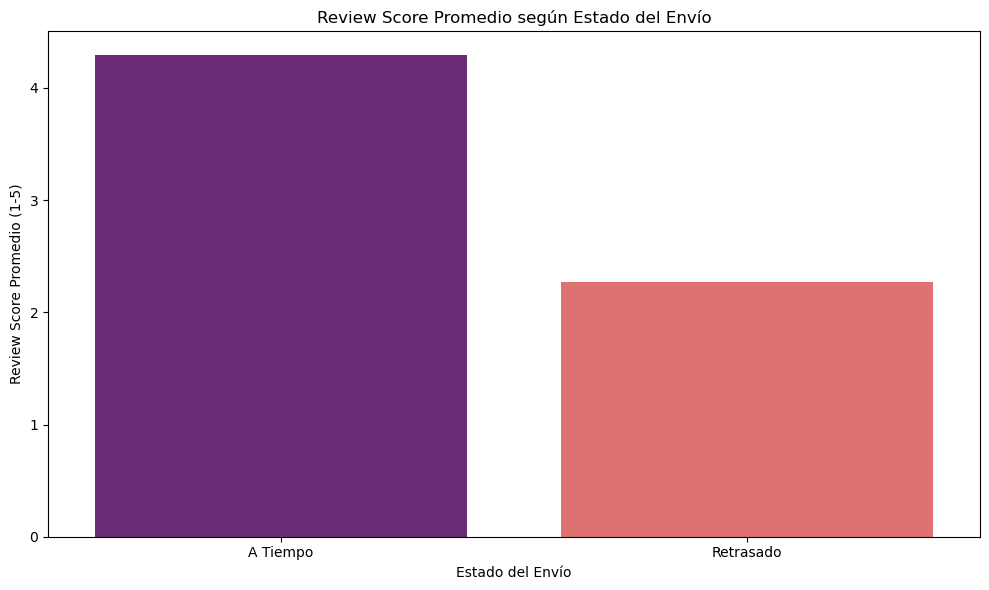

In [49]:
# Si los días de anticipación son menores a 0, el pedido se retrasó.
df_logistica_tiempos_indiv['estado_envio'] = df_logistica_tiempos_indiv['dias_anticipacion'].apply(
    lambda x: 'Retrasado' if x < 0 else 'A Tiempo'
)

print("--- Impacto en el Review Score Promedio ---")
print(df_logistica_tiempos_indiv.groupby('estado_envio')['review_score'].mean())

print("\n--- Distribución Porcentual de las Calificaciones ---")
print(pd.crosstab(df_logistica_tiempos_indiv['estado_envio'], df_logistica_tiempos_indiv['review_score'], normalize='index') * 100)

plt.figure(figsize=(10, 6))

# Gráfico de barras para comparar el Review Score promedio
sns.barplot(x='estado_envio', y='review_score', data=df_logistica_tiempos_indiv, palette='magma', errorbar=None)
plt.title('Review Score Promedio según Estado del Envío')
plt.xlabel('Estado del Envío')
plt.ylabel('Review Score Promedio (1-5)')

plt.tight_layout()
plt.show()